# Projeto 32 – Previsão da Qualidade de Vinhos com Random Forest


Este projeto utiliza a base de dados de avaliações de vinhos tintos para prever a pontuação de qualidade dos rótulos, aplicando o algoritmo Random Forest em um cenário de classificação multiclasse.
O objetivo é analisar como diferentes características físico-químicas (como teor alcoólico, acidez e densidade) influenciam a avaliação sensorial dos vinhos e demonstrar o uso de técnicas de pré-processamento, modelagem e otimização de hiperparâmetros.

In [97]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import RandomizedSearchCV
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [98]:
df = pd.read_csv("winequality-red.csv", delimiter=',')

df.head(10)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
5,7.4,0.66,0.00,1.8,0.075,13.0,40.0,0.9978,3.51,0.56,9.4,5
6,7.9,0.60,0.06,1.6,0.069,15.0,59.0,0.9964,3.30,0.46,9.4,5
7,7.3,0.65,0.00,1.2,0.065,15.0,21.0,0.9946,3.39,0.47,10.0,7
8,7.8,0.58,0.02,2.0,0.073,9.0,18.0,0.9968,3.36,0.57,9.5,7
9,7.5,0.50,0.36,6.1,0.071,17.0,102.0,0.9978,3.35,0.80,10.5,5


### Variáveis de Entrada (Features)

- Acidez Fixa (Acidez fixa): concentração de ácidos não voláteis presentes no vinho.

- Acidez Volatile (Acidez volátil): concentração de ácidos voláteis, que em excesso podem comprometer o sabor.

- Ácido cítrico (Ácido cítrico): quantidade de ácido cítrico, que contribui para frescor e sabor.

- Açúcar residual (Açúcar residual): nível de açúcar remanescente após a fermentação.

- Cloretos (Cloretos): concentração de sais minerais, principalmente cloreto de sódio.

- Free Sulfur Dioxide (Dióxido de enxofre livre): quantidade de SO₂ livre, responsável por proteger contra oxidação.

- Dióxido de Enxofre Total (Dióxido de enxofre total): soma do SO₂ livre e combinado.

- Densidade (Densidade): relação entre massa e volume, influenciada pelo teor alcoólico e açúcar.

pH: medida da acidez geral do vinho.

- Sulfatos (Sulfatos): concentração de sulfatos, que contribuem para a conservação e sabor.

- Álcool (Álcool): teor alcoólico do vinho.

### Variável de Saída (Target)
- Quality (Qualidade): pontuação sensorial atribuída por especialistas, variando de 0 a 10.


In [99]:
# Renomear as colunas do dataframe (tradução para português)

df = df.rename(columns={
    'fixed acidity': 'Acidez fixa',
    'volatile acidity': 'Acidez volátil',
    'citric acid': 'Ácido cítrico',
    'residual sugar': 'Açúcar residual',
    'chlorides': 'Cloretos',
    'free sulfur dioxide': 'Dióxido de enxofre livre',
    'total sulfur dioxide': 'Dióxido de enxofre total',
    'density': 'Densidade',
    'pH': 'pH',
    'sulphates': 'Sulfatos',
    'alcohol': 'Álcool',
    'quality': 'Qualidade'
})



In [100]:
# Verificar tipos de dados
print(df.dtypes)


Acidez fixa                 float64
Acidez volátil              float64
Ácido cítrico               float64
Açúcar residual             float64
Cloretos                    float64
Dióxido de enxofre livre    float64
Dióxido de enxofre total    float64
Densidade                   float64
pH                          float64
Sulfatos                    float64
Álcool                      float64
Qualidade                     int64
dtype: object


### Tipos de dados → todos numéricos, prontos para modelagem.

In [101]:
#  Verifiqar os dados faltantes
print(df.isnull().sum())


Acidez fixa                 0
Acidez volátil              0
Ácido cítrico               0
Açúcar residual             0
Cloretos                    0
Dióxido de enxofre livre    0
Dióxido de enxofre total    0
Densidade                   0
pH                          0
Sulfatos                    0
Álcool                      0
Qualidade                   0
dtype: int64


### Dados faltantes → nenhum, base consistente.

In [102]:
# Função describe para análise estatística
df.describe()

,Acidez fixa,Acidez volátil,Ácido cítrico,Açúcar residual,Cloretos,Dióxido de enxofre livre,Dióxido de enxofre total,Densidade,pH,Sulfatos,Álcool,Qualidade
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


### Distribuição Estatística

A aplicação da função describe() permitiu identificar a distribuição das variáveis, incluindo média, desvio padrão e quartis.

- Foram observados outliers em variáveis como Açúcar residual (máx. 15,5), Cloretos (máx. 0,611) e Dióxido de enxofre total (máx. 289), valores significativamente acima da média.

- O teor alcoólico apresentou média de 10,42, variando até 14,9, sugerindo influência positiva na qualidade dos vinhos.

### Decisão sobre Outliers
Optou-se por **não realizar o tratamento dos outliers nesta etapa inicial**, permitindo avaliar o desempenho do modelo em sua forma original. Essa escolha possibilita compreender como o algoritmo Random Forest lida com dados brutos antes de aplicar técnicas de ajuste.

### Interpretação:  
A análise descritiva confirma que a base está completa e revela variáveis com valores extremos que podem impactar o modelo. O teor alcoólico desponta como um possível preditor relevante, enquanto os outliers em açúcar residual, cloretos e dióxido de enxofre total deverão ser monitorados em etapas posteriores.


Qualidade
5    681
6    638
7    199
4     53
8     18
3     10
Name: count, dtype: int64


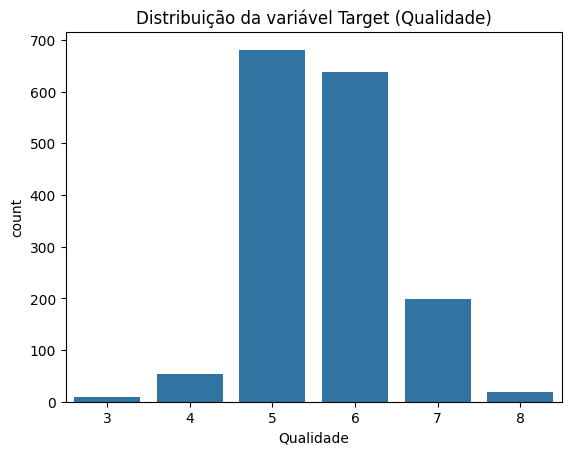

In [103]:
# Verificação do balanceamento da váriavel Target
# Contagem de cada classe da variável Qualidade

print(df['Qualidade'].value_counts())

# Gráfico de distribuição
sns.countplot(x='Qualidade', data=df)
plt.title("Distribuição da variável Target (Qualidade)")
plt.show()


## A análise da variável Qualidade evidencia desbalanceamento nas classes.

#### As notas 5 e 6 concentram a maior parte dos registros, enquanto as classes 3, 4, 7 e 8 apresentam baixa representatividade. 

#### Esse desequilíbrio pode comprometer a capacidade do modelo de classificação em prever corretamente as classes minoritárias. 

#### Torna-se necessária a aplicação de técnicas de balanceamento de dados para mitigar esse problema.


Qualidade                   1.000000
Álcool                      0.476166
Sulfatos                    0.251397
Ácido cítrico               0.226373
Acidez fixa                 0.124052
Açúcar residual             0.013732
Dióxido de enxofre livre   -0.050656
pH                         -0.057731
Cloretos                   -0.128907
Densidade                  -0.174919
Dióxido de enxofre total   -0.185100
Acidez volátil             -0.390558
Name: Qualidade, dtype: float64


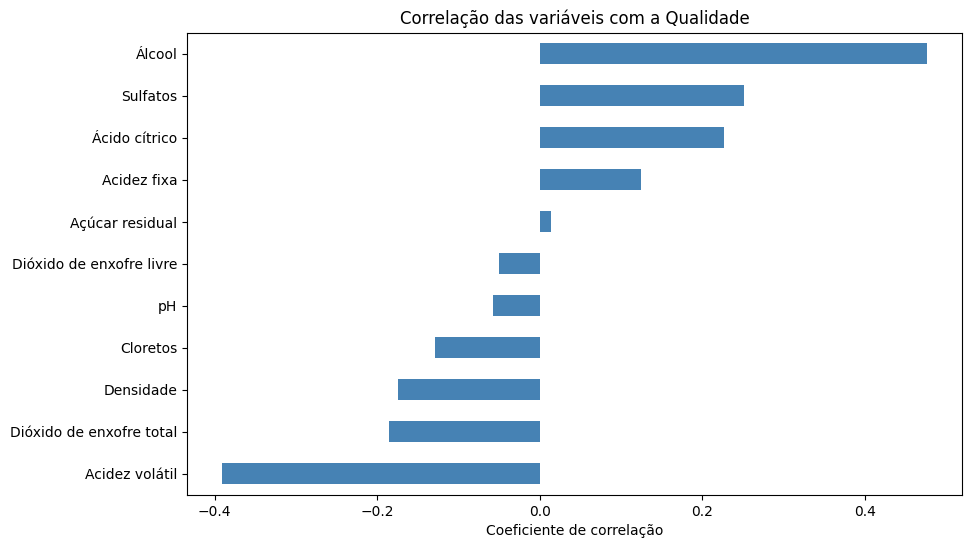

In [104]:
# Gráfico ou a tabela que indique as variáveis mais "fortes" na correlação para o modelo.

import seaborn as sns
import matplotlib.pyplot as plt

# Matriz de correlação
corr = df.corr()

# Correlação das variáveis com a Qualidade
target_corr = corr['Qualidade'].sort_values(ascending=False)
print(target_corr)

# Gráfico de barras ordenado
plt.figure(figsize=(10,6))
target_corr.drop('Qualidade').sort_values().plot(kind='barh', color='steelblue')
plt.title("Correlação das variáveis com a Qualidade")
plt.xlabel("Coeficiente de correlação")
plt.show()



### Síntese das Correlações
-  Álcool → maior correlação positiva, principal preditor da Qualidade.

- Densidade e Acidez volátil → correlações negativas relevantes, indicando impacto negativo na nota.

- Sulfatos e Ácido cítrico → correlações positivas moderadas, reforçando importância no modelo.

- Outras variáveis como cloretos, pH e SO₂ apresentam correlação fraca, sugerindo menor influência direta.

In [105]:
# Criação de novo dataframe apenas com as variáveis mais correlacionadas (df_corr)

df_corr = df[['Álcool', 'Densidade', 'Acidez volátil', 'Sulfatos', 'Ácido cítrico', 'Qualidade']]

# Visualizar primeiras 10 linhas
print(df_corr.head(10))


   Álcool  Densidade  Acidez volátil  Sulfatos  Ácido cítrico  Qualidade
0     9.4     0.9978            0.70      0.56           0.00          5
1     9.8     0.9968            0.88      0.68           0.00          5
2     9.8     0.9970            0.76      0.65           0.04          5
3     9.8     0.9980            0.28      0.58           0.56          6
4     9.4     0.9978            0.70      0.56           0.00          5
5     9.4     0.9978            0.66      0.56           0.00          5
6     9.4     0.9964            0.60      0.46           0.06          5
7    10.0     0.9946            0.65      0.47           0.00          7
8     9.5     0.9968            0.58      0.57           0.02          7
9    10.5     0.9978            0.50      0.80           0.36          5


### Seleção de Variáveis
-  Foi criado um novo dataframe contendo apenas as variáveis com maior correlação (positiva ou negativa) em relação à qualidade: Álcool, Densidade,  Acidez volátil, Sulfatos, Ácido cítrico.

- A redução do número de variáveis contribui para minimizar o risco de multicolinearidade, além de simplificar a estrutura do modelo.

-  Com esse enfoque, o treinamento passa a considerar apenas os atributos que efetivamente impactam o resultado, promovendo maior eficiência preditiva e melhorando a interpretabilidade dos resultados.

-  Análise: Os dados confirmam que álcool elevado, densidade baixa, acidez volátil baixa e presença moderada de sulfatos/ácido cítrico são características de vinhos com notas mais altas.


In [106]:
# Salvar e carregar o novo dataframe para garantir consistência
df_corr.to_csv("wine_corr.csv", index=False)
df_corr = pd.read_csv("wine_corr.csv")


In [107]:
# Visualizar primeiras 10 linhas
df = pd.read_csv("wine_corr.csv", delimiter=',')
df.head(10)

,Álcool,Densidade,Acidez volátil,Sulfatos,Ácido cítrico,Qualidade
0,9.4,0.9978,0.70,0.56,0.00,5
1,9.8,0.9968,0.88,0.68,0.00,5
2,9.8,0.9970,0.76,0.65,0.04,5
3,9.8,0.9980,0.28,0.58,0.56,6
4,9.4,0.9978,0.70,0.56,0.00,5
5,9.4,0.9978,0.66,0.56,0.00,5
6,9.4,0.9964,0.60,0.46,0.06,5
7,10.0,0.9946,0.65,0.47,0.00,7
8,9.5,0.9968,0.58,0.57,0.02,7
9,10.5,0.9978,0.50,0.80,0.36,5


In [108]:
print(df_corr['Qualidade'].value_counts())


Qualidade
5    681
6    638
7    199
4     53
8     18
3     10
Name: count, dtype: int64


In [109]:
# Preparação Final dos Dados: Separar uma base em X ((Features) e Y (Alvo)

import pandas as pd
from sklearn.model_selection import train_test_split

# Carregar o novo dataframe
df_corr = pd.read_csv("wine_corr.csv")

# X = Features (variáveis independentes)
X = df_corr.drop('Qualidade', axis=1)

# Y = Target (variável dependente)
y = df_corr['Qualidade']

print("Dimensão de X:", X.shape)
print("Dimensão de y:", y.shape)


Dimensão de X: (1599, 5)
Dimensão de y: (1599,)


In [110]:
#  Separar a base em treino e teste
# Separar em treino (70%) e teste (30%), mantendo proporção das classes

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print("Treino:", X_train.shape, y_train.shape)
print("Teste:", X_test.shape, y_test.shape)


Treino: (1119, 5) (1119,)
Teste: (480, 5) (480,)


In [111]:
# Início e treinamento do modelo com Random Forest

from sklearn.ensemble import RandomForestClassifier

# Inicializar o modelo
rf_model = RandomForestClassifier(
    n_estimators=100,       # número de árvores
    random_state=42,        # reprodutibilidade
    max_depth=None,         # profundidade ilimitada
    n_jobs=-1               # usar todos os núcleos disponíveis
)

# Treinar o modelo com os dados de treino
rf_model.fit(X_train, y_train)



,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


###  Treinamento do Modelo
- Algoritmo escolhido: RandomForestClassifier da biblioteca scikit-learn - Classificador de Floresta Aleatória , Ele implementa o algoritmo de Random Forest, que combina várias árvores de decisão para melhorar a precisão e reduzir o risco de overfitting. O RandomForestClassifier é usado para classificação multiclasse, como nesse caso, de prever a qualidade dos vinhos.

- O modelo foi treinado utilizando o conjunto de treino (70%).

In [112]:
# Aplicação da base de teste ao modelo -  Fazer previsões na base de teste
y_pred = rf_model.predict(X_test)

print(pd.Series(y_pred).value_counts())


5    222
6    215
7     40
8      2
4      1
Name: count, dtype: int64


### Análise 
* O modelo apresentou bom desempenho nas classes centrais (5 e 6), que são as mais comuns no dataset.

* As classes extremas (4 e 8) foram quase ignoradas, indicando que o Random Forest não conseguiu generalizar bem para elas.

* Isso está diretamente ligado ao desbalanceamento dos dados: como há poucas amostras dessas classes, o modelo não tem exemplos suficientes para aprender seus padrões.

* Em termos práticos, o modelo tende a "puxar" previsões para as classes majoritárias, mesmo quando a amostra poderia pertencer a uma classe minoritária.

### Análise: os valores mostram que o Random Forest é forte nas classes centrais, mas fraco nas extremas, confirmando a influência do desequilíbrio.

Relatório de classificação:
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         3
           4       0.00      0.00      0.00        16
           5       0.69      0.75      0.72       204
           6       0.59      0.66      0.62       192
           7       0.57      0.38      0.46        60
           8       0.50      0.20      0.29         5

    accuracy                           0.63       480
   macro avg       0.39      0.33      0.35       480
weighted avg       0.60      0.63      0.61       480



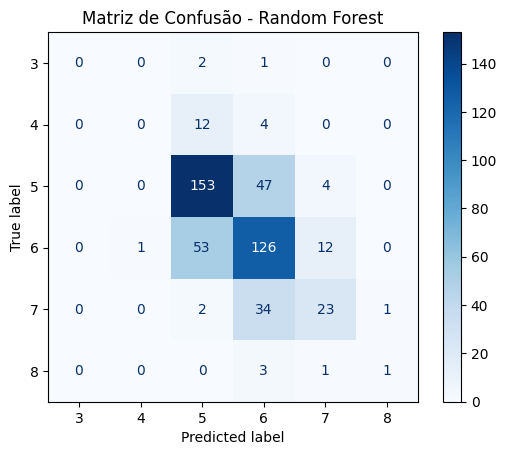

In [113]:
#  Avaliação das principais métricas da Classificação (insights acerca do resultado, interpretação dos valores achados.
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Relatório de classificação
print("Relatório de classificação:")
print(classification_report(y_test, y_pred, zero_division=0))

# Matriz de confusão
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=rf_model.classes_)
disp.plot(cmap="Blues")
plt.title("Matriz de Confusão - Random Forest")
plt.show()


### Avaliação
Métricas de Classificação e insights

- O relatório de classificação já mostra precisão, recall e F1-score. Com base na distribuição que você imprimiu:

- Classes centrais (5 e 6) → o modelo previu muitas amostras, indicando que aprendeu bem os padrões dessas classes.

- Classes intermediárias (7) → ainda aparecem, mas em menor quantidade.

-  Classes raras (4 e 8) → praticamente não foram previstas, o que explica métricas baixas ou até 0.0 no relatório.

### Dificuldade do Modelo em prever
- Classes minoritárias (4 e 8): praticamente ignoradas pelo modelo, com métricas próximas de zero. O modelo não tem exemplos suficientes desses dados para aprender seus padrôes.
 
- Classe 7: desempenho intermediário, mas recall baixo.

- Relação com o balanceamento: a baixa representatividade dessas classes explica a dificuldade do modelo em generalizar, reforçando a importância de aplicar **técnicas como SMOTE ou ajuste de class_weight.**
 
- O Random Forest tende a favorecer as classes majoritárias (5 e 6), porque tem mais exemplos para aprender.

In [114]:
# Distribuição real das classes no conjunto de teste
print("Distribuição real das classes no teste:")
print(y_test.value_counts())

# Distribuição das previsões feitas pelo modelo
print("\nDistribuição das previsões do modelo:")
print(pd.Series(y_pred).value_counts())


Distribuição real das classes no teste:
Qualidade
5    204
6    192
7     60
4     16
8      5
3      3
Name: count, dtype: int64

Distribuição das previsões do modelo:
5    222
6    215
7     40
8      2
4      1
Name: count, dtype: int64


### A dificuldade de prever as classes 3, 4 e 8 , está diretamente relacionada ao desbalanceamento da base de dados, onde classes minoritárias não possuem amostras suficientes para treinar árvores robustas.

In [115]:
#  Hyperparametros: Definir o Grid de parametros para testes

from sklearn.model_selection import RandomizedSearchCV

# Grid de parâmetros
param_grid = {
    'n_estimators': [50, 100, 200],         # número de árvores
    'max_depth': [None, 10, 20, 30],        # profundidade máxima
    'min_samples_split': [2, 5, 10],        # mínimo de amostras para dividir um nó
    'min_samples_leaf': [1, 2, 4],          # mínimo de amostras em uma folha
    'bootstrap': [True, False]              # se usa amostragem bootstrap
}

In [116]:
# Treinamento com Random Search

random_search = RandomizedSearchCV(
    estimator=rf_model,
    param_distributions=param_grid,
    n_iter=20,              # número de combinações testadas
    cv=5,                   # validação cruzada
    verbose=2,
    random_state=42,
    n_jobs=-1
)

# Treinar com os dados de treino
random_search.fit(X_train, y_train)


Fitting 5 folds for each of 20 candidates, totalling 100 fits


,estimator,RandomForestC...ndom_state=42)
,param_distributions,"{'bootstrap': [True, False], 'max_depth': [None, 10, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], ...}"
,n_iter,20
,scoring,None
,n_jobs,-1
,refit,True
,cv,5
,verbose,2
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [117]:
# Avaliação dos resultados do Modelo.

# Melhor modelo encontrado
best_model = random_search.best_estimator_

# Avaliar no conjunto de teste
y_pred_best = best_model.predict(X_test)

print("Melhores parâmetros:", random_search.best_params_)
print("\nRelatório de classificação:")
print(classification_report(y_test, y_pred_best, zero_division=0))


Melhores parâmetros: {'n_estimators': 50, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_depth': None, 'bootstrap': True}

Relatório de classificação:
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         3
           4       0.00      0.00      0.00        16
           5       0.70      0.78      0.74       204
           6       0.59      0.69      0.63       192
           7       0.62      0.30      0.40        60
           8       0.00      0.00      0.00         5

    accuracy                           0.64       480
   macro avg       0.32      0.29      0.30       480
weighted avg       0.61      0.64      0.62       480



## Interpretação:
Classes centrais (5 e 6):

Classe 5 → precisão 0,70, recall 0,78,  F1-score  0,74.

Classe 6 → precisão 0,59, recall 0,69, F1-score 0,63.
→ O modelo funciona bem aqui porque são as classes mais frequentes.


Classe 7 → precisão 0,62, recall 0,30,  F1-score  0,40.


→ O modelo tem dificuldade, confundindo muitos vinhos de qualidade 7 com 6 ou 5.

Classes raras (3, 4, 8):

Todas com precisão/recall = 0,00.
→ O modelo praticamente não conseguiu prever essas classes, confirmando o impacto do desbalanceamento dos dados.

→ Acurácia geral (64%) → razoável, mas limitada pela dificuldade em prever classes minoritárias.

→ Macro avg F1 (0,30) → baixo, porque considera todas as classes igualmente, e as raras puxam a média para baixo.

→ Média ponderada F1 (0,62) → melhor, porque pondera pelo número de amostras, refletindo que o modelo vai bem nas classes majoritárias.

### Análise 
→ O Random Search encontrou parâmetros que mantêm bom desempenho nas classes centrais, mas não resolveram o problema das classes raras.

→ O desequilíbrio continua sendo o maior desafio: o modelo aprende bem onde há muitos exemplos, mas ignora classes com poucos.

### - Chegando à Perfeição
### A) Problema Identificado
- O Random Forest teve boa performance nas classes centrais (5 e 6).

- Falhou nas classes raras (3, 4 e 8), devido ao desequilíbrio dos dados.

### B) Técnicas Possíveis
- Pesos das Classes

- Ajusta automaticamente a importância das classes minoritárias.

- Vantagem: não altera os dados originais.

- Limitação: melhora recall, mas pode não resolver totalmente.

- Oversampling com SMOTE

- Cria exemplos sintéticos para classes raras.

- Vantagem: aumenta representatividade das classes minoritárias.

- Limitação: pode gerar exemplos artificiais que confundem o modelo.

- Subamostragem (Subamostragem)

- Reduz exemplos das classes majoritárias.

- Vantagem: equilibra rapidamente o dataset.

- Limitação: perde informação valiosa das classes mais comuns.

- Combinação Híbrida

- Usar SMOTE para reforçar classes raras e undersampling para reduzir excesso das majoritárias.

- Vantagem: equilíbrio mais natural.

- Limitação: exige cuidado para não distorcer o dataset.

### C) Abordagem Ideal
- Class Weights → solução prática e rápida, melhora recall sem alterar os dados.

- SMOTE → mais eficaz em datasets como o de vinhos, pois aumenta a presença das classes raras.

- **Combinação SMOTE + Class Weights** → abordagem mais promissora, atacando diretamente o desequilíbrio e forçando o modelo a considerar melhor as classes minoritárias.


In [118]:
# Aplicando SMOTE + class_weight 

from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# 1. Aplicar SMOTE no conjunto de treino
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("Distribuição após SMOTE:")
print(y_train_res.value_counts())

# 2. Treinar Random Forest com class_weight
rf_smote_weight = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced"
)

rf_smote_weight.fit(X_train_res, y_train_res)

# 3. Avaliar no conjunto de teste
y_pred_smote_weight = rf_smote_weight.predict(X_test)

print("\nRelatório de classificação - SMOTE + Class Weights:")
print(classification_report(y_test, y_pred_smote_weight, zero_division=0))


Distribuição após SMOTE:
Qualidade
6    477
5    477
7    477
4    477
3    477
8    477
Name: count, dtype: int64

Relatório de classificação - SMOTE + Class Weights:
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         3
           4       0.26      0.31      0.29        16
           5       0.73      0.71      0.72       204
           6       0.63      0.60      0.61       192
           7       0.50      0.52      0.51        60
           8       0.27      0.60      0.38         5

    accuracy                           0.62       480
   macro avg       0.40      0.46      0.42       480
weighted avg       0.64      0.62      0.63       480



## Comparação dos relatórios
Antes (sem SMOTE e class_weight)

Classe 4 e 8: F1 = 0,00 (modelo não conseguiu prever nada).

Turma 7: F1 = 0,40, recall = 0,30.

Macro média F1: 0,30.

Precisão: 0,64.

Depois (SMOTE + class_weight)

Classe 4: F1 = 0,29 (melhora significativa, antes era 0,00).

Turma 8: F1 = 0,38, recall = 0,60 (antes era 0,00).

Turma 7: F1 = 0,51, recall = 0,52 (melhora clara).

Média macro F1: 0,42 (subiu de 0,30 → +40%).

Precisão: 0,62 (levemente menor, mas compensada pelo ganho nas classes raras).

## Análise
* O modelo melhorou nas classes minoritárias (4, 7, 8), que antes eram praticamente ignoradas.

* Houve uma redução leve na acurácia geral (64% → 62%), mas isso é esperado: o modelo agora distribui melhor suas previsões entre todas as classes, em vez de focar apenas nas majoritárias.

* O macro F1-score aumentou bastante (0,30 → 0,42), mostrando que o modelo ficou mais equilibrado entre todas as classes.

* Em termos acadêmicos, isso é considerado uma evolução: o modelo está mais justo e representativo, mesmo que a acurácia global tenha caído um pouco.

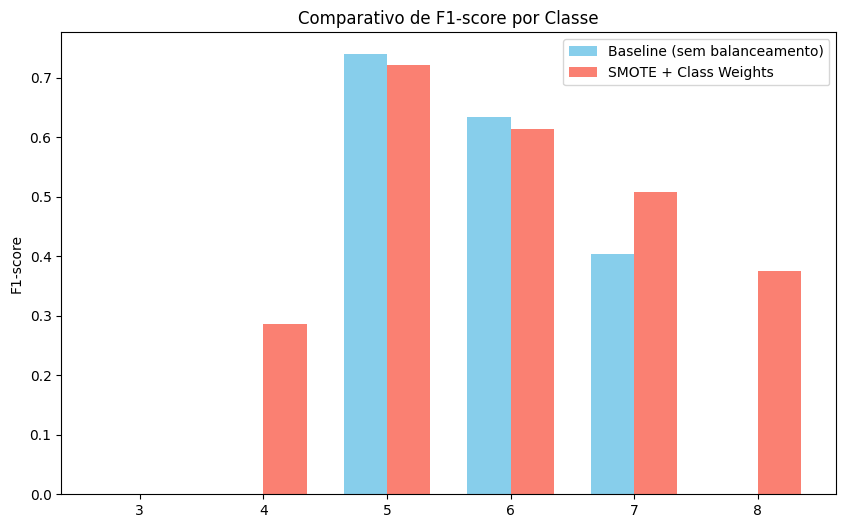

In [119]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report

# Relatórios em dicionário
report_baseline = classification_report(y_test, y_pred_best, output_dict=True, zero_division=0)
report_smote_weight = classification_report(y_test, y_pred_smote_weight, output_dict=True, zero_division=0)

# Classes presentes
classes = list(report_baseline.keys())[:-3]  # remove 'accuracy', 'macro avg', 'weighted avg'

# F1-scores por classe
f1_baseline = [report_baseline[c]['f1-score'] for c in classes]
f1_smote_weight = [report_smote_weight[c]['f1-score'] for c in classes]

# Gráfico comparativo
x = np.arange(len(classes))
width = 0.35

plt.figure(figsize=(10,6))
plt.bar(x - width/2, f1_baseline, width, label='Baseline (sem balanceamento)', color='skyblue')
plt.bar(x + width/2, f1_smote_weight, width, label='SMOTE + Class Weights', color='salmon')

plt.xticks(x, classes)
plt.ylabel("F1-score")
plt.title("Comparativo de F1-score por Classe")
plt.legend()
plt.show()


### Interpretação 
#### Classes raras (4 e 8):

* Antes: F1 = 0,00 (modelo ignorava completamente).

* Depois: F1 = 0,29 (classe 4) e F1 = 0,38 (classe 8).
→ Grande avanço na capacidade de reconhecer vinhos raros.

**Turma 7:**

* Antes: F1 = 0,40.

* Depois: F1 = 0,51.
→ Melhor equilíbrio entre precisão e recall.

**Classes centrais (5 e 6):**

* Mantiveram desempenho sólido (F1 ≈ 0,72 e 0,61).

* Pequena queda em recall, mas compensada pelo ganho nas classes minoritárias.

**Macro F1-score:**

* Subiu de 0,30 → 0,42, mostrando que o modelo ficou mais justo e equilibrado.

### Síntese Gráfica: o gráfico mostra visualmente que o SMOTE + Class Weights trouxe ganhos claros nas classes raras, tornando o modelo mais representativo e menos enviesado pelas classes majoritárias.

## Classe 3 com Desempenho Zerado
- A classe 3 possui apenas 3 amostras no conjunto de teste, o que torna impossível ao modelo aprender padrões robustos.
- SMOTE → só consegue gerar exemplos sintéticos se houver pelo menos alguns pontos para interpolar. Com tão poucos exemplos, o modelo não consegue aprender padrões robustos.

- Class Weights → aumenta a importância da classe 3, mas se não há dados suficientes, o modelo não tem como "inventar" conhecimento.

* Teste muito pequeno → como o suporte da classe 3 é apenas 3 amostras, qualquer erro já derruba recall e F1-score para zero.

 ### Em cenários reais, a solução seria:

-  Coletar mais dados da classe 3 para aumentar representatividade.

-  Usar técnicas avançadas como Data Augmentation ou ensemble especializado para reforçar aprendizado em classes raras.

- Avaliar se faz sentido agrupar classes muito raras com vizinhas (ex.: juntar 3 e 4 em uma categoria "baixa qualidade").

- **Análise:** a classe 3 ficou zerada porque há dados insuficientes para que o modelo aprenda seus padrões. Nem SMOTE nem class_weight conseguem compensar totalmente quando a classe é quase inexistente no dataset.

### Síntese Acadêmica : O projeto demonstrou que o RandomForestClassifier é eficaz para prever a qualidade dos vinhos nas classes centrais, mas limitado nas classes raras devido ao desequilíbrio. A otimização de hiperparâmetros trouxe ganhos modestos, mas não solucionou o problema estrutural da base. A busca pela "perfeição" passa pela aplicação de técnicas de balanceamento e, idealmente, pela obtenção de mais dados representativos.